# Notebook 18 — Intervalos de predicción, calibración y Conformal Prediction

En este notebook estudiaremos tres conceptos fundamentales para cuantificar la incertidumbre en modelos de regresión:

- intervalos de predicción;
- calibración;
- Conformal Prediction.

## Objetivos

Al finalizar este notebook podrás:

- distinguir predicción puntual e intervalo de predicción;
- construir intervalos suponiendo errores normales;
- medir cobertura empírica;
- comprender qué significa que un modelo esté calibrado;
- implementar **Split Conformal Prediction**;
- estudiar el efecto del nivel de confianza;
- comparar amplitud y cobertura de distintos intervalos.

Utilizaremos datos sintéticos generados con `make_regression`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
pd.options.display.float_format="{:,.4f}".format


## 1. Generación de datos

In [2]:
X,y=make_regression(
    n_samples=2500,
    n_features=8,
    n_informative=6,
    noise=25,
    random_state=RANDOM_STATE
)

y=y+20*np.sin(X[:,0])

X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.40,random_state=RANDOM_STATE)

X_cal,X_test,y_cal,y_test=train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=RANDOM_STATE)

print(X_train.shape,X_cal.shape,X_test.shape)


(1500, 8) (500, 8) (500, 8)


## 2. Modelo base

In [3]:
model=RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1)

model.fit(X_train,y_train)

pred_train=model.predict(X_train)
pred_cal=model.predict(X_cal)
pred_test=model.predict(X_test)

print("MAE train:",mean_absolute_error(y_train,pred_train))
print("MAE test :",mean_absolute_error(y_test,pred_test))


MAE train: 14.773593125280744
MAE test : 40.483046971379764


## 3. Intervalo normal (didáctico)

Supondremos que los residuos siguen una distribución aproximadamente normal.

Este supuesto rara vez se cumple exactamente, pero sirve como referencia.


In [4]:
residuals=y_train-pred_train
sigma=residuals.std(ddof=1)

lower_normal=pred_test-1.96*sigma
upper_normal=pred_test+1.96*sigma

coverage=((y_test>=lower_normal)&(y_test<=upper_normal)).mean()

print("Cobertura empírica:",coverage)
print("Ancho promedio:",
      np.mean(upper_normal-lower_normal))


Cobertura empírica: 0.59
Ancho promedio: 77.55398189615738


## 4. Split Conformal Prediction

In [5]:
cal_scores=np.abs(y_cal-pred_cal)

alpha=0.10

q=np.quantile(
    cal_scores,
    np.ceil((len(cal_scores)+1)*(1-alpha))/len(cal_scores),
    method="higher"
)

lower_cp=pred_test-q
upper_cp=pred_test+q

coverage_cp=((y_test>=lower_cp)&(y_test<=upper_cp)).mean()

print("Cuantil conformal:",q)
print("Cobertura:",coverage_cp)
print("Ancho promedio:",
      np.mean(upper_cp-lower_cp))


Cuantil conformal: 86.85498988212865
Cobertura: 0.906
Ancho promedio: 173.70997976425727


## 5. Comparación de coberturas

In [6]:
comparison=pd.DataFrame({
    "Método":["Intervalo normal","Split Conformal"],
    "Cobertura":[coverage,coverage_cp],
    "Ancho promedio":[
        np.mean(upper_normal-lower_normal),
        np.mean(upper_cp-lower_cp)
    ]
})

comparison


,Método,Cobertura,Ancho promedio
0,Intervalo normal,0.5900,77.5540
1,Split Conformal,0.9060,173.7100


## 6. Visualización

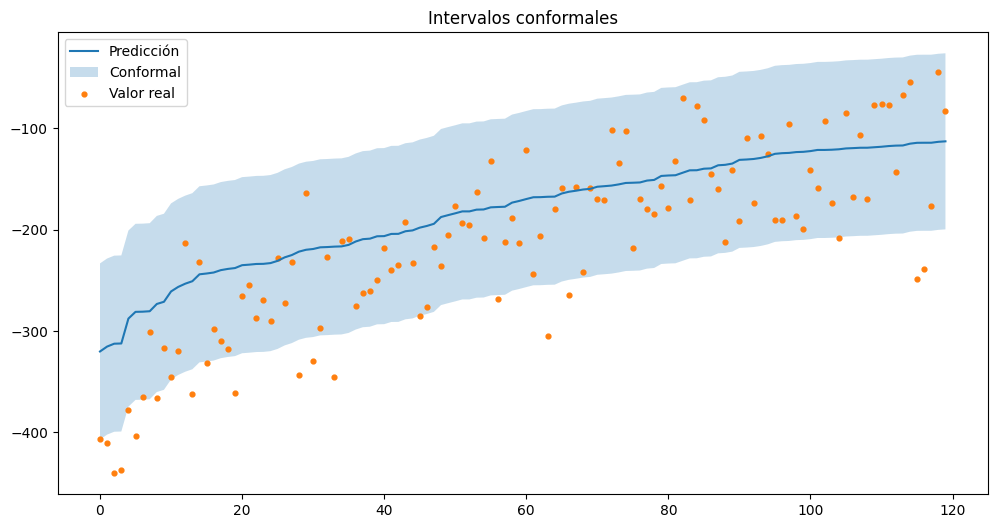

In [7]:
idx=np.argsort(pred_test)[:120]

plt.figure(figsize=(12,6))

plt.plot(pred_test[idx],label="Predicción")

plt.fill_between(
    np.arange(len(idx)),
    lower_cp[idx],
    upper_cp[idx],
    alpha=.25,
    label="Conformal"
)

plt.scatter(
    np.arange(len(idx)),
    y_test[idx],
    s=12,
    label="Valor real"
)

plt.legend()
plt.title("Intervalos conformales")
plt.show()


## 7. Cobertura para distintos niveles

In [8]:
rows=[]

for confidence in [0.80,0.90,0.95,0.99]:

    alpha=1-confidence

    q=np.quantile(
        cal_scores,
        np.ceil((len(cal_scores)+1)*(1-alpha))/len(cal_scores),
        method="higher"
    )

    lower=pred_test-q
    upper=pred_test+q

    rows.append({
        "Confianza":confidence,
        "Cobertura":
        ((y_test>=lower)&(y_test<=upper)).mean(),
        "Ancho":
        np.mean(upper-lower)
    })

pd.DataFrame(rows)


,Confianza,Cobertura,Ancho
0,0.8000,0.8040,129.2990
1,0.9000,0.9060,173.7100
2,0.9500,0.9500,218.6526
3,0.9900,0.9960,318.3793


## 8. ¿Qué significa calibración?

En regresión, un método está bien calibrado si la cobertura observada se aproxima a la cobertura nominal.

Por ejemplo, un intervalo nominal del 90% debería contener aproximadamente el 90% de las observaciones futuras.


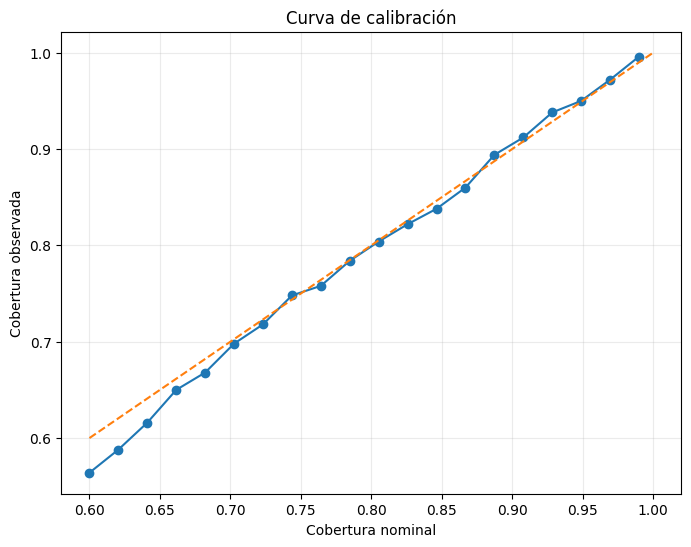

In [9]:
confidence=np.linspace(.60,.99,20)
observed=[]

for c in confidence:

    alpha=1-c

    q=np.quantile(
        cal_scores,
        np.ceil((len(cal_scores)+1)*(1-alpha))/len(cal_scores),
        method="higher"
    )

    lower=pred_test-q
    upper=pred_test+q

    observed.append(
        ((y_test>=lower)&(y_test<=upper)).mean()
    )

plt.figure(figsize=(8,6))
plt.plot(confidence,observed,marker="o")
plt.plot([0.6,1],[0.6,1],"--")
plt.xlabel("Cobertura nominal")
plt.ylabel("Cobertura observada")
plt.title("Curva de calibración")
plt.grid(alpha=.25)
plt.show()


## 9. Ventajas de Conformal Prediction

- No requiere normalidad.
- Funciona con prácticamente cualquier modelo.
- Garantiza cobertura marginal bajo intercambiabilidad.
- Es sencillo de implementar.
- Se adapta fácilmente a modelos modernos.

## Limitaciones

- Garantía marginal, no necesariamente condicional.
- Requiere que entrenamiento, calibración y prueba sean intercambiables.
- Puede producir intervalos amplios cuando el problema es muy ruidoso.


## 10. Experimentos sugeridos

1. Cambia el modelo base.
2. Incrementa el ruido.
3. Reduce el tamaño del conjunto de calibración.
4. Compara diferentes niveles de confianza.
5. Analiza cobertura por regiones del espacio de entrada.
6. Compara con cuantile regression si está disponible.


## Resumen

En este notebook:

- construimos intervalos normales;
- medimos cobertura empírica;
- implementamos Split Conformal Prediction;
- comparamos cobertura y amplitud;
- estudiamos calibración;
- analizamos el efecto del nivel de confianza.

Conformal Prediction proporciona garantías estadísticas muy atractivas sin imponer supuestos fuertes sobre el modelo, siempre que se satisfaga el supuesto de **intercambiabilidad**.